# Week 3 — Day 3: Logistic Regression & Classification Metrics

**Program:** BinX Tech AI & ML Internship — Phase 2, Week 3
**Topic:** Logistic regression, why accuracy is misleading, the confusion matrix, precision/recall/F1, AUC-ROC
**Dataset:** Breast Cancer Wisconsin dataset (built into scikit-learn) — binary classification (malignant vs. benign)


## 1. From Regression to Classification

Despite its name, **logistic regression is a classification model** — it predicts a category, not a number. It computes the same weighted sum as linear regression, then passes that number through the **sigmoid function**, which squashes any value into a probability between 0 and 1. If that probability crosses a threshold (usually 0.5), it predicts the positive class.

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)  # class probabilities
```


## 2. Why Accuracy Alone Is Misleading

Accuracy — the fraction of correct predictions — is the obvious metric, and it is **dangerously misleading on imbalanced data**.

If 95% of customers don't churn, a model that always predicts "no churn" scores 95% accuracy while being completely useless. This is exactly why classification needs richer metrics than accuracy alone.


## 3. The Confusion Matrix

Every classification metric is built on top of this table:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) — missed |
| **Actual Negative** | False Positive (FP) — false alarm | True Negative (TN) |

```python
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
```


## 4. Precision, Recall & F1

| Metric | Formula | Answers |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of everything predicted positive, how much was actually right? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did we catch? |
| **F1-score** | harmonic mean of the two | A single balanced score when both matter |

This trade-off is a **real decision**, not a formula:
- Disease screening → recall matters most (never miss a real case)
- Spam filter → precision matters most (never block a real email)


## 5. AUC-ROC

The ROC curve plots the trade-off between catching positives (true positive rate) and raising false alarms (false positive rate) across **every possible threshold**, not just 0.5.

**AUC** (Area Under the Curve) summarizes that whole curve as a single number:
- 0.5 = random guessing
- 1.0 = perfect separation

It's the standard way to compare classifiers independently of any single threshold choice.

```python
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probabilities[:, 1])
```


---

## Hands-On Lab: Building a Classifier

**Goal:** train a logistic regression classifier, evaluate it beyond plain accuracy, and reason about the precision/recall trade-off for this specific problem.

**Steps:**
1. Load the dataset, split into `X`/`y`, then train/test split.
2. Train a `LogisticRegression` model and generate predictions + class probabilities.
3. Produce the confusion matrix and interpret each cell.
4. Compute precision, recall, and F1 with `classification_report`, and interpret them.
5. Decide whether precision or recall matters more for this specific problem, and justify it.
6. Compute the AUC-ROC and document what it says about the model.


### Step 1: Load the dataset and create the train/test split

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the dataset as a pandas DataFrame
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

# target: 0 = malignant, 1 = benign
print(df["target"].value_counts())
print("\nTarget names:", cancer.target_names)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nX_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)


target
1    357
0    212
Name: count, dtype: int64

Target names: ['malignant' 'benign']

X_train shape: (455, 30)
X_test shape:  (114, 30)


### Step 2: Train a LogisticRegression model

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)  # column 1 = probability of class "1" (benign)

print("First 5 predictions:   ", predictions[:5])
print("First 5 probabilities:\n", probabilities[:5])


First 5 predictions:    [1 0 0 1 1]
First 5 probabilities:
 [[1.20905813e-01 8.79094187e-01]
 [9.99999970e-01 3.00686612e-08]
 [9.98409464e-01 1.59053644e-03]
 [1.21075048e-03 9.98789250e-01]
 [1.39377177e-04 9.99860623e-01]]


### Step 3: Confusion matrix

In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(
    cm,
    index=["Actual malignant (0)", "Actual benign (1)"],
    columns=["Predicted malignant (0)", "Predicted benign (1)"]
)
cm_df


,Predicted malignant (0),Predicted benign (1)
Actual malignant (0),39,4
Actual benign (1),1,70


### Step 4: Precision, recall, and F1 with classification_report

In [4]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=cancer.target_names))


              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Step 5: Precision vs. recall — which matters more here?

*(Write your own justification here.)*

Think about the cost of each type of mistake in this specific problem:
- A **false negative** (predicting benign when the tumor is actually malignant) means missing real cancer.
- A **false positive** (predicting malignant when it's actually benign) means unnecessary worry/follow-up testing.

Which mistake is worse for a real patient, and which metric (precision or recall) should this model be optimized for?


### Step 6: AUC-ROC

AUC-ROC: 0.998


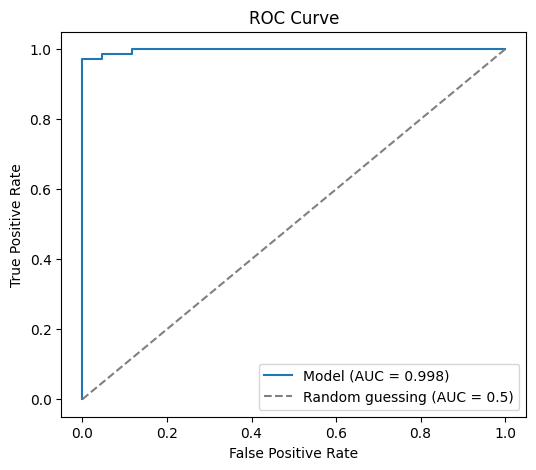

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# probabilities[:, 1] = probability of the positive class (benign = 1)
auc = roc_auc_score(y_test, probabilities[:, 1])
print(f"AUC-ROC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Step 6 (continued): What does the AUC score say about this model?

*(Write your own explanation here.)*

Your answer should cover: how close the AUC is to 1.0, what that means about the model's ability to separate malignant from benign cases across all thresholds (not just 0.5), and whether that matches the precision/recall numbers you found in Step 4.
